In [2]:
import lightgbm as lgb
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
import polars as pl
import numpy as np
import optuna
import pandas as pd

In [3]:
from pathlib import Path

path = Path.cwd()
if not Path(path, "data").exists():
    path = path.parent

In [3]:
def evaluar_modelo(y_true, y_pred, nombre_set="Test"):
    """
    Evalúa predicciones de regresión y devuelve un diccionario con las métricas.
    Soporta entradas como Series de Polars, listas o arrays de NumPy.
    """
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    media_real = np.mean(y_true)
    media_pred = np.mean(y_pred)

    print(f"\n--- REPORTE DE RENDIMIENTO: {nombre_set} ---")
    print(f"MAE  (Error Absoluto Medio):       {mae:.4f}")
    print(f"RMSE (Raíz del Error Cuadrático):  {rmse:.4f}")
    print(f"R²   (Coef. de Determinación):     {r2:.4f}")
    print("-" * 45)
    print(f"Propina media real del set:        {media_real:.4f}")
    print(f"Propina media predicha:            {media_pred:.4f}")
    print("-" * 45)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Media_Real": media_real,
        "Media_Pred": media_pred,
    }

# **Arquitectura 1: lgbm con objective tweedie**

In [ ]:
df_train = pl.read_parquet(path / "data" / "train_tip_final_unificado_ligero.parquet")
df_val = pl.read_parquet(path / "data" / "val_tip_final_unificado_ligero.parquet")

In [ ]:
df_train.schema

Schema([('PULocationID', Int16),
        ('DOLocationID', Int16),
        ('tip_amount', Int16),
        ('VendorID', Int8),
        ('fare_amount', Int16),
        ('pickup_latitude', Float64),
        ('pickup_longitude', Float64),
        ('dropoff_latitude', Float64),
        ('dropoff_longitude', Float64),
        ('distance', Float64),
        ('direction', Float64),
        ('pickup_dist_nyc', Float64),
        ('dropoff_dist_nyc', Float64),
        ('pickup_dist_chp', Float64),
        ('dropoff_dist_chp', Float64),
        ('pickup_dist_exp', Float64),
        ('dropoff_dist_exp', Float64),
        ('temperature_2m', Float64),
        ('precipitation', Float64),
        ('rain', Float64),
        ('snowfall', Float64),
        ('temp_discomfort', Float64),
        ('daylight_duration', Float64),
        ('is_daylight', Int32),
        ('month', Int8),
        ('dayofyear', Int16),
        ('weekday', Int8),
        ('hour', Float64)])

In [ ]:
categorical_cols = [
    "VendorID",
    "weekday",
    "month",
    "PULocationID",
    "DOLocationID",
    "is_daylight"
]
input_cols = [col for col in df_train.columns if col not in ["tip_amount"]]
objective = "tip_amount"

x_train, y_train = df_train.select(input_cols), df_train.select(objective).to_numpy()
x_val, y_val = df_val.select(input_cols), df_val.select(objective).to_numpy()

In [7]:
train_data = lgb.Dataset(
    data=x_train,
    label=y_train,
    feature_name=input_cols,
    categorical_feature=categorical_cols,
    free_raw_data=True,
)

val_data = lgb.Dataset(
    data=x_val, label=y_val, reference=train_data, feature_name=input_cols
)

lgbm_params = {
    "objective": "tweedie", #gamma, regression, huber
    "boosting": "gbdt",
    "metric": "rmse",
    "verbose": -1,
    "tweedie_variance_power": 1.55, #quitar
    "learning_rate": 0.05, 
    "num_leaves": 150, 
    "max_depth": 10,
    "min_data_in_leaf": 1000, 
    "feature_fraction": 0.8, 
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "lambda_l2": 1.0, 
    "max_bin": 255,
}

model_lgb = lgb.train(
    params=lgbm_params,
    train_set=train_data,
    num_boost_round=5000,
    valid_sets=[train_data, val_data],
    valid_names=["Entrenamiento", "Validacion"],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=100)],
)

c:\Users\jabal\OtrosProyectos\C-ity-enjoyers\.venv\Lib\site-packages\lightgbm\basic.py:374: UserWarning: Converting column-vector to 1d array
  _log_warning("Converting column-vector to 1d array")


Training until validation scores don't improve for 50 rounds
[100]	Entrenamiento's rmse: 259.779	Validacion's rmse: 277.8
[200]	Entrenamiento's rmse: 258.656	Validacion's rmse: 277.149
[300]	Entrenamiento's rmse: 258.266	Validacion's rmse: 277.043
[400]	Entrenamiento's rmse: 257.987	Validacion's rmse: 276.967
[500]	Entrenamiento's rmse: 257.756	Validacion's rmse: 276.948
[600]	Entrenamiento's rmse: 257.538	Validacion's rmse: 276.94
Early stopping, best iteration is:
[555]	Entrenamiento's rmse: 257.634	Validacion's rmse: 276.935


In [ ]:
model_lgb.save_model(path / "data" / "lgbm_rmse276.935_tip_monofase.txt")

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

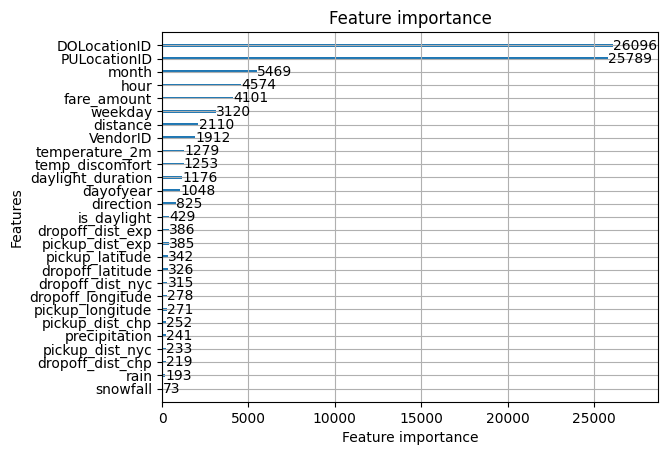

In [24]:
lgb.plot_importance(model_lgb)

Prácticamente agrupa por zonas, mes y hora. Los datos de la temperatura o las horas de sol son bastante útiles. Sin embargo la lluvia o la nieve no lo son tanto. Los datos de distancias apenas aportan pero algo ayudan al modelo.

In [26]:
predicciones = model_lgb.predict(x_val)
metricas_finales = evaluar_modelo(
    y_val, predicciones, nombre_set="Conjunto completo (val) con todo el dataset"
)

c:\Users\jabal\OtrosProyectos\C-ity-enjoyers\.venv\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")



--- REPORTE DE RENDIMIENTO: Conjunto completo (val) con todo el dataset ---
MAE  (Error Absoluto Medio):       155.3370
RMSE (Raíz del Error Cuadrático):  276.9348
R²   (Coef. de Determinación):     0.4348
---------------------------------------------
Propina media real del set:        208.6363
Propina media predicha:            206.6896
---------------------------------------------


No es un resultado demasiado bueno. Hay que tener en cuenta que el conjunto está lleno de tip=0 lo cual es complejo de predecir ya que no es determinista cuando alguien va a dejar propina o no.

In [33]:
df_train.group_by("VendorID").agg(
    sin_propina=pl.col("tip_amount").filter(pl.col("tip_amount") == 0).count(),
    con_propina=pl.col("tip_amount").filter(pl.col("tip_amount") > 0).count()
).with_columns(
    porcentaje_sin_propina=pl.col("sin_propina")/(pl.col("sin_propina")+pl.col("con_propina")),
).sort("VendorID")

VendorID,sin_propina,con_propina,porcentaje_sin_propina
i8,u32,u32,f64
0,251650,4110689,0.057687
1,147128,1115162,0.116556
2,3739954,860070,0.813029
3,4143679,1046448,0.798377


# **Arquitectura 2: Modelo Hurdle de Dos Fases**

El **Modelo Hurdle** es una estrategia de modelado diseñada para datos con un **exceso de ceros** (zero-inflation), donde la decisión de que un evento ocurra es independiente de su magnitud. En este proyecto, desglosamos la predicción de propinas en dos etapas:

1. **Fase de Clasificación (La "Valla"):** Un modelo binario que determina la probabilidad de que un viaje genere propina ($P(\text{Tip} > 0)$). Esta fase captura factores de comportamiento y probabilidad base según el tipo de servicio (Taxi vs. VTC).
2. **Fase de Regresión (El "Experto"):** Un modelo de regresión entrenado exclusivamente en casos con propina positiva. Se encarga de estimar la cuantía económica basándose en variables de tarifa, distancia y geografía.



**Predicción Final:** La estimación final se obtiene calculando el valor esperado:
$$\text{Tip Final} = P(\text{Propina} > 0) \times \text{Monto Estimado}$$

Esta estructura permite que el regresor no sea "contaminado" por el gran volumen de viajes sin propina, logrando una especialización que optimiza la precisión en la estimación de los montos reales.

## Fase I: Predecir probabilidad de que no den tip (clasificador)

In [4]:
df_train = pl.scan_parquet(path / "data" / "train_tip_final_unificado_ligero.parquet")
df_val = pl.scan_parquet(path / "data" / "val_tip_final_unificado_ligero.parquet")

In [ ]:
df_train = df_train.with_columns((pl.col("tip_amount") > 0).cast(pl.Int8).alias("has_tip")).collect()
df_val = df_val.with_columns((pl.col("tip_amount") > 0).cast(pl.Int8).alias("has_tip")).collect()

In [ ]:
categorical_cols = [
    "VendorID",
    "weekday",
    "month",
    "PULocationID",
    "DOLocationID",
    "is_daylight"
]
input_cols = [col for col in df_train.columns if col not in ["tip_amount", "has_tip"]]
objective = "has_tip"

x_train, y_train = df_train.select(input_cols), df_train.select(objective).to_numpy()
x_val, y_val = df_val.select(input_cols), df_val.select(objective).to_numpy()

In [44]:
train_data = lgb.Dataset(
    data=x_train,
    label=y_train,
    feature_name=input_cols,
    categorical_feature=categorical_cols,
    #weight=weights_train,
    free_raw_data=True,
)

val_data = lgb.Dataset(
    data=x_val, label=y_val, reference=train_data, feature_name=input_cols
)

params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'learning_rate': 0.1,
    'verbose': -1
}

model_classif_lgb = lgb.train(
    params=params,
    train_set=train_data,
    num_boost_round=3000,
    valid_sets=[train_data, val_data],
    valid_names=["Entrenamiento", "Validacion"],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=100)],
)

Training until validation scores don't improve for 50 rounds
[100]	Entrenamiento's binary_logloss: 0.363373	Validacion's binary_logloss: 0.37844
[200]	Entrenamiento's binary_logloss: 0.361389	Validacion's binary_logloss: 0.377136
[300]	Entrenamiento's binary_logloss: 0.360011	Validacion's binary_logloss: 0.376347
[400]	Entrenamiento's binary_logloss: 0.359036	Validacion's binary_logloss: 0.375978
[500]	Entrenamiento's binary_logloss: 0.358132	Validacion's binary_logloss: 0.375636
[600]	Entrenamiento's binary_logloss: 0.357363	Validacion's binary_logloss: 0.375467
[700]	Entrenamiento's binary_logloss: 0.356702	Validacion's binary_logloss: 0.375424
Early stopping, best iteration is:
[656]	Entrenamiento's binary_logloss: 0.356975	Validacion's binary_logloss: 0.375412


In [59]:
model_classif_lgb.save_model(path / "data" / "lgbm_0.375412_tip_1stfase.txt")

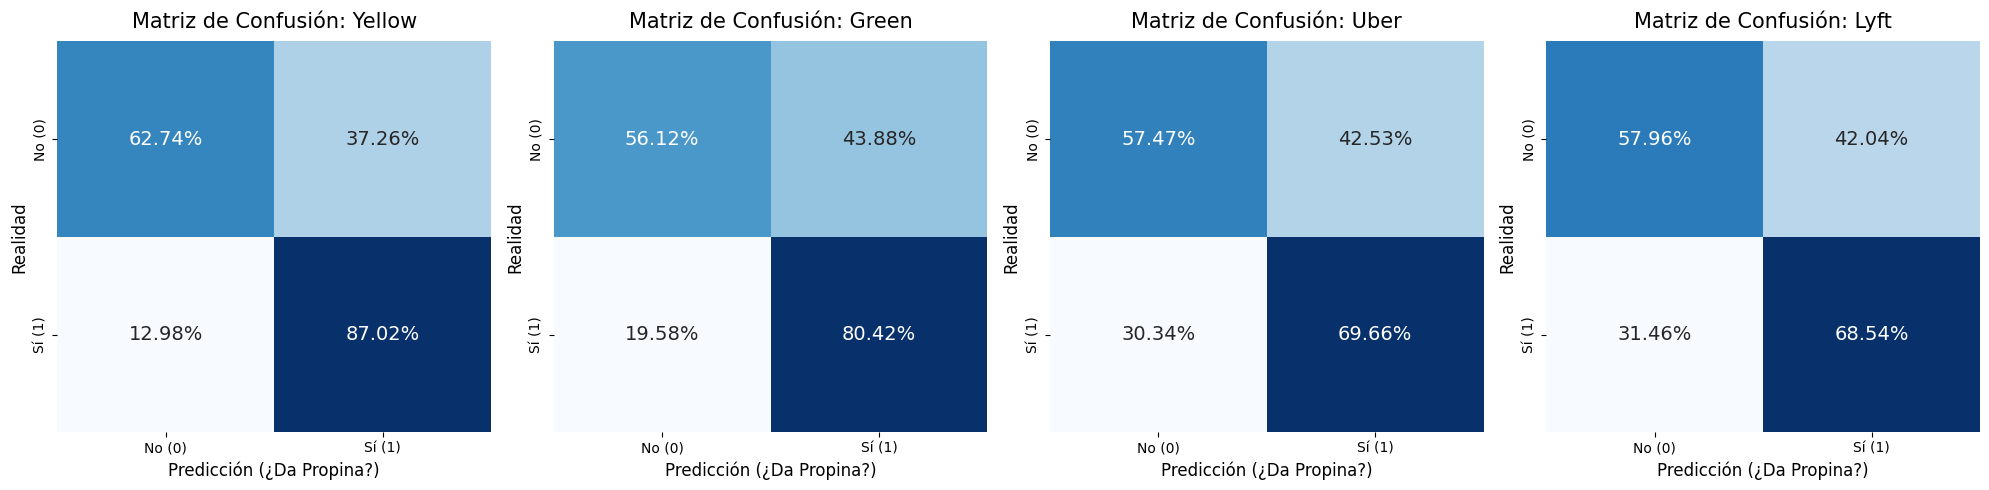


--- REPORTE PARA Yellow ---
              precision    recall  f1-score   support

           0       0.30      0.63      0.41      9704
           1       0.96      0.87      0.91    107602

    accuracy                           0.85    117306
   macro avg       0.63      0.75      0.66    117306
weighted avg       0.91      0.85      0.87    117306


--- REPORTE PARA Green ---
              precision    recall  f1-score   support

           0       0.21      0.56      0.30      2616
           1       0.95      0.80      0.87     28529

    accuracy                           0.78     31145
   macro avg       0.58      0.68      0.59     31145
weighted avg       0.89      0.78      0.82     31145


--- REPORTE PARA Uber ---
              precision    recall  f1-score   support

           0       0.89      0.57      0.70    126751
           1       0.27      0.70      0.39     28897

    accuracy                           0.60    155648
   macro avg       0.58      0.64      0.55 

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

def plot_confusion_matrices(model, df_test, X_test_cols):
    """
    Genera matrices de confusión coloreadas por tipo de taxi.
    """
    preds_prob = model.predict(df_test[X_test_cols].to_pandas())
    preds_class = (preds_prob > 0.5).astype(int)
    
    df_eval = df_test.with_columns(
        pl.Series(name="pred", values=preds_class),
        pl.Series(name="target", values=df_test["has_tip"])
    ).to_pandas()

    taxis = df_eval['VendorID'].unique()
    n_taxis = len(taxis)
    dic_taxis = ["Yellow", "Green", "Uber", "Lyft"]

    fig, axes = plt.subplots(1, n_taxis, figsize=(5 * n_taxis, 5))
    if n_taxis == 1: axes = [axes] # Manejo de caso un solo taxi

    for i, taxi in enumerate(taxis):
        df_taxi = df_eval[df_eval['VendorID'] == taxi]
        
        cm = confusion_matrix(df_taxi['target'], df_taxi['pred'], normalize='true')
        
        # Dibujar con Seaborn
        sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues', ax=axes[i], 
                    cbar=False, annot_kws={"size": 14})
        
        # Estética
        axes[i].set_title(f'Matriz de Confusión: {dic_taxis[taxi]}', fontsize=15, pad=10)
        axes[i].set_xlabel('Predicción (¿Da Propina?)', fontsize=12)
        axes[i].set_ylabel('Realidad', fontsize=12)
        axes[i].set_xticklabels(['No (0)', 'Sí (1)'])
        axes[i].set_yticklabels(['No (0)', 'Sí (1)'])

    plt.tight_layout()
    plt.show()

    # Imprimir reporte de métricas por consola para detalle técnico
    for taxi in taxis:
        df_taxi = df_eval[df_eval['VendorID'] == taxi]
        print(f"\n--- REPORTE PARA {dic_taxis[taxi]} ---")
        print(classification_report(df_taxi['target'], df_taxi['pred']))

plot_confusion_matrices(model_classif_lgb, df_val, input_cols)

## Fase II: Predecir la tip en sí

In [4]:
df_train = pl.scan_parquet(path / "data" / "train_tip_final_unificado.parquet")
df_val = pl.scan_parquet(path / "data" / "val_tip_final_unificado.parquet")

In [5]:
df_train = df_train.filter((pl.col("tip_amount") > 0) & (pl.col("fare_amount") > 0)).collect()
df_val = df_val.filter((pl.col("tip_amount") > 0) & (pl.col("fare_amount") > 0)).collect()

In [6]:
categorical_cols = [
    "VendorID",
    "weekday",
    "month",
    "PULocationID",
    "DOLocationID",
    "is_daylight"
]
input_cols = [col for col in df_train.columns if col not in ["tip_amount"]]
objective = "tip_amount"

x_train, y_train = df_train.select(input_cols), df_train.select(objective).to_numpy()
x_val, y_val = df_val.select(input_cols), df_val.select(objective).to_numpy()

In [ ]:
train_data = lgb.Dataset(
    data=x_train,
    label=y_train,
    feature_name=input_cols,
    categorical_feature=categorical_cols,
    free_raw_data=True,
)

val_data = lgb.Dataset(
    data=x_val, label=y_val, reference=train_data, feature_name=input_cols
)

lgbm_params = {
    "objective": "tweedie",
    "boosting": "gbdt",
    "metric": "rmse",
    "verbose": -1,
    "tweedie_variance_power": 1.55, 
    "learning_rate": 0.05, 
    "num_leaves": 150, 
    "max_depth": 10,
    "min_data_in_leaf": 1000, 
    "feature_fraction": 0.8, 
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "lambda_l2": 1.0, 
    "max_bin": 255,
}

model_lgb = lgb.train(
    params=lgbm_params,
    train_set=train_data,
    num_boost_round=5000,
    valid_sets=[train_data, val_data],
    valid_names=["Entrenamiento", "Validacion"],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=100)],
)

c:\Users\jabal\OtrosProyectos\C-ity-enjoyers\.venv\Lib\site-packages\lightgbm\basic.py:374: UserWarning: Converting column-vector to 1d array
  _log_warning("Converting column-vector to 1d array")


Training until validation scores don't improve for 50 rounds
[100]	Entrenamiento's rmse: 226.244	Validacion's rmse: 232.237
[200]	Entrenamiento's rmse: 224.983	Validacion's rmse: 231.888
[300]	Entrenamiento's rmse: 224.465	Validacion's rmse: 231.819
Early stopping, best iteration is:
[301]	Entrenamiento's rmse: 224.461	Validacion's rmse: 231.819


In [ ]:
model_lgb.save_model(path / "data" / "lgbm_rmse231.819_tip_2ndfase.txt")

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

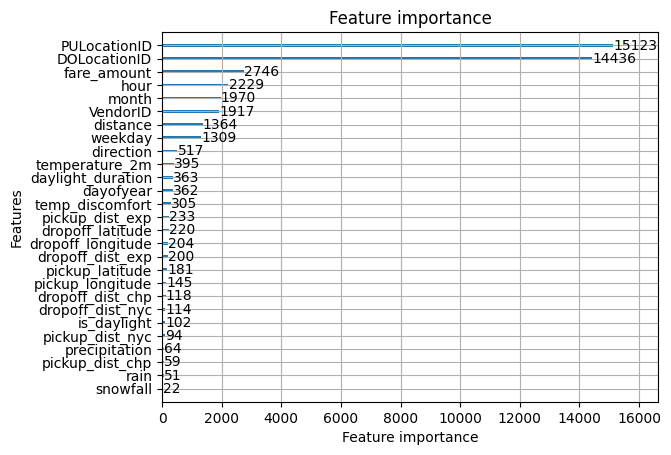

In [ ]:
lgb.plot_importance(model_lgb)

In [ ]:
predicciones = model_lgb.predict(x_val)
metricas_finales = evaluar_modelo(
    y_val, predicciones, nombre_set="Solo Tip (val) con rmse segunda fase"
)

c:\Users\jabal\OtrosProyectos\C-ity-enjoyers\.venv\Lib\site-packages\lightgbm\basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")



--- REPORTE DE RENDIMIENTO: Tip (val) con rmse segunda fase ---
MAE  (Error Absoluto Medio):       127.2861
RMSE (Raíz del Error Cuadrático):  231.8186
R²   (Coef. de Determinación):     0.6952
---------------------------------------------
Propina media real del set:        494.8240
Propina media predicha:            487.9338
---------------------------------------------


Este modelo es aceptable aunque no podemos compararlo con el otro ya que este trabaja exclusivamente con los viajes que sí dieron tip.

## Comparación con baseline

In [7]:
df_train1 = pl.scan_parquet(path / "data" / "train_tip_final_unificado_ligero.parquet")

df_train1 = df_train1.with_columns((pl.col("tip_amount") > 0).cast(pl.Int8).alias("has_tip")).collect()

In [8]:
input_cols = [col for col in df_train1.columns if col not in ["tip_amount", "has_tip"]]

In [12]:
df_train2 = pl.scan_parquet(path / "data" / "train_tip_final_unificado.parquet")

df_train2 = df_train2.filter((pl.col("tip_amount") > 0) & (pl.col("fare_amount") > 0)).collect()

In [13]:
df_test = pl.read_parquet(path / "data" / "train_tip_final_unificado_ligero.parquet")

In [14]:
print("Calculando la Baseline desde los datos de entrenamiento...")

# ==========================================
# 1. CONSTRUIR LA BASELINE (A partir del Train)
# ==========================================

# Fase 1 Baseline: Probabilidad histórica de propina por tipo de taxi
baseline_prob = df_train1.group_by("VendorID").agg(
    pl.col("has_tip").mean().alias("base_prob")
)

# Fase 2 Baseline: Media de propina por origen, destino y taxi (Solo donde hubo propina)
baseline_amount = (
    df_train2.group_by(["PULocationID", "DOLocationID", "VendorID"])
    .agg(pl.col("tip_amount").mean().alias("base_amount"))
)

# Media global por VendorID de "respaldo" (por si en el test sale una ruta que no vimos en el train)
baseline_amount_fallback = (
    df_train2.group_by("VendorID")
    .agg(pl.col("tip_amount").mean().alias("fallback_amount"))
)

# ==========================================
# 2. APLICAR BASELINE Y ML AL TEST SET
# ==========================================

print("Generando predicciones sobre el Test Set...")

# Unimos las reglas de la baseline al dataset de test
df_eval = (
    df_test.join(baseline_prob, on="VendorID", how="left")
    .join(baseline_amount, on=["PULocationID", "DOLocationID", "VendorID"], how="left")
    .join(baseline_amount_fallback, on="VendorID", how="left")
    # Si la ruta no existía en train, usamos el fallback
    .with_columns(
        base_amount = pl.col("base_amount").fill_null(pl.col("fallback_amount"))
    )
)

# Predicción Final Baseline: Probabilidad * Monto
df_eval = df_eval.with_columns(
    pred_baseline = pl.col("base_prob") * pl.col("base_amount")
)

Calculando la Baseline desde los datos de entrenamiento...
Generando predicciones sobre el Test Set...


In [17]:
# MODELO UNIFICADO
model_unif = lgb.Booster(model_file=path / "data" / "lgbm_rmse276.935_tip_monofase.txt")

In [15]:
# MODELO QUE PREDICE PROBABILIDAD DE DAR PROPINA
model_fase1 = lgb.Booster(model_file=path / "data" / "lgbm_0.375412_tip_1stfase.txt")

In [16]:
# MODELO QUE PREDICE LA PROPINA EN SÍ
model_fase2 = lgb.Booster(model_file=path / "data" / "lgbm_rmse231.819_tip_2ndfase.txt")

In [18]:
X_test = df_eval.select(input_cols).to_pandas()

ml_unif = model_unif.predict(X_test)

fase1 = model_fase1.predict(X_test)
fase2 = model_fase2.predict(X_test)

df_eval = df_eval.with_columns(
    ml_unif=pl.Series(ml_unif),
    fase1=pl.Series(fase1),
    fase2=pl.Series(fase2),
).with_columns(
    pred_ml = pl.col("fase1")*pl.col("fase2"),
)
ml_unif, fase1, fase2 = None, None, None

In [24]:
X_test = df_eval.filter((pl.col("tip_amount") > 0) & (pl.col("fare_amount") > 0)).select(input_cols).to_pandas()

ml_unif = model_unif.predict(X_test)

fase2 = model_fase2.predict(X_test)

In [27]:
dic_taxis = ["Yellow", "Green", "Uber", "Lyft"]

In [29]:
# 1. Preparamos los datos pasándolos a Pandas para las métricas
df_pd = df_eval.to_pandas()

# Aseguramos la existencia del modelo mixto y la baseline total
df_pd["pred_mixto"] = df_pd["base_prob"] * df_pd["fase2"]
df_pd["pred_baseline"] = df_pd["base_prob"] * df_pd["base_amount"]

# ==============================================================================
# ESCENARIO 1: CONJUNTO COMPLETO (TODOS LOS DATOS, CEROS INCLUIDOS)
# ==============================================================================
print("\n" + "="*80)
print("ESCENARIO 1: CONJUNTO COMPLETO (BASELINE vs FULL ML vs MIXTO vs HURDLE)")
print("="*80)

y_true_full = df_pd["tip_amount"]

# Métricas Globales
rmse_base_full = root_mean_squared_error(y_true_full, df_pd["pred_baseline"])
rmse_unif_full = root_mean_squared_error(y_true_full, df_pd["ml_unif"])
rmse_mixt_full = root_mean_squared_error(y_true_full, df_pd["pred_mixto"])
rmse_hurd_full = root_mean_squared_error(y_true_full, df_pd["pred_ml"])

mae_base_full = mean_absolute_error(y_true_full, df_pd["pred_baseline"])
mae_unif_full = mean_absolute_error(y_true_full, df_pd["ml_unif"])
mae_mixt_full = mean_absolute_error(y_true_full, df_pd["pred_mixto"])
mae_hurd_full = mean_absolute_error(y_true_full, df_pd["pred_ml"])

print("\n[MÉTRICAS GLOBALES - CONJUNTO COMPLETO]")
print(f"BASELINE TOTAL   -> RMSE: {rmse_base_full:.4f} | MAE: {mae_base_full:.4f}")
print(f"MODELO UNIFORME  -> RMSE: {rmse_unif_full:.4f} | MAE: {mae_unif_full:.4f}")
print(f"MODELO MIXTO     -> RMSE: {rmse_mixt_full:.4f} | MAE: {mae_mixt_full:.4f}")
print(f"MODELO HURDLE    -> RMSE: {rmse_hurd_full:.4f} | MAE: {mae_hurd_full:.4f}")

print("\n[MEJORA SOBRE LA BASELINE EN RMSE]")
print(f"Unif (Tweedie) : {((rmse_base_full - rmse_unif_full) / rmse_base_full) * 100:+.2f}%")
print(f"Mixto          : {((rmse_base_full - rmse_mixt_full) / rmse_base_full) * 100:+.2f}%")
print(f"Hurdle (2 Fases): {((rmse_base_full - rmse_hurd_full) / rmse_base_full) * 100:+.2f}%")

print("\n[DESGLOSE POR TIPO DE TAXI - RMSE]")
print(f"{'Taxi'.ljust(8)} | {'Baseline'.ljust(10)} | {'Unif'.ljust(10)} | {'Mixto'.ljust(10)} | {'Hurdle'.ljust(10)}")
print("-" * 65)
for taxi in df_pd['VendorID'].unique():
    mask = df_pd['VendorID'] == taxi
    r_b = root_mean_squared_error(y_true_full[mask], df_pd.loc[mask, "pred_baseline"])
    r_u = root_mean_squared_error(y_true_full[mask], df_pd.loc[mask, "ml_unif"])
    r_m = root_mean_squared_error(y_true_full[mask], df_pd.loc[mask, "pred_mixto"])
    r_h = root_mean_squared_error(y_true_full[mask], df_pd.loc[mask, "pred_ml"])
    print(f"{dic_taxis[taxi].ljust(8)} | {r_b:.4f}   | {r_u:.4f}   | {r_m:.4f}   | {r_h:.4f}")


ESCENARIO 1: CONJUNTO COMPLETO (BASELINE vs FULL ML vs MIXTO vs HURDLE)

[MÉTRICAS GLOBALES - CONJUNTO COMPLETO]
BASELINE TOTAL   -> RMSE: 278.2208 | MAE: 157.4533
MODELO UNIFORME  -> RMSE: 257.6336 | MAE: 145.2349
MODELO MIXTO     -> RMSE: 271.2770 | MAE: 152.9445
MODELO HURDLE    -> RMSE: 257.7050 | MAE: 145.6160

[MEJORA SOBRE LA BASELINE EN RMSE]
Unif (Tweedie) : +7.40%
Mixto          : +2.50%
Hurdle (2 Fases): +7.37%

[DESGLOSE POR TIPO DE TAXI - RMSE]
Taxi     | Baseline   | Unif       | Mixto      | Hurdle    
-----------------------------------------------------------------
Yellow   | 268.3438   | 238.5871   | 253.5465   | 238.0782
Green    | 276.7691   | 253.9909   | 269.6657   | 251.2547
Uber     | 277.8373   | 261.5494   | 273.7700   | 262.1494
Lyft     | 286.9307   | 270.1301   | 283.5845   | 270.8158


In [30]:
# ==============================================================================
# ESCENARIO 2: DATOS FILTRADOS (SOLO VIAJES CON PROPINA Y TARIFA > 0)
# ==============================================================================
print("\n\n" + "="*80)
print("ESCENARIO 2: DATOS FILTRADOS (BASELINE F2 vs FASE 2 HURDLE vs FULL ML)")
print("="*80)

# Filtramos el dataframe que ya tiene todas las predicciones
mask_filter = (df_pd["tip_amount"] > 0) & (df_pd["fare_amount"] > 0)
df_filt = df_pd[mask_filter]

y_true_filt = df_filt["tip_amount"]

# Métricas Filtradas
rmse_base_f2 = root_mean_squared_error(y_true_filt, df_filt["base_amount"])
rmse_hurd_f2 = root_mean_squared_error(y_true_filt, df_filt["fase2"])
rmse_unif_f2 = root_mean_squared_error(y_true_filt, df_filt["ml_unif"])

mae_base_f2 = mean_absolute_error(y_true_filt, df_filt["base_amount"])
mae_hurd_f2 = mean_absolute_error(y_true_filt, df_filt["fase2"])
mae_unif_f2 = mean_absolute_error(y_true_filt, df_filt["ml_unif"])

print("\n[MÉTRICAS GLOBALES - DATOS FILTRADOS (FASE 2)]")
print(f"BASELINE FASE 2  -> RMSE: {rmse_base_f2:.4f} | MAE: {mae_base_f2:.4f}")
print(f"HURDLE FASE 2    -> RMSE: {rmse_hurd_f2:.4f} | MAE: {mae_hurd_f2:.4f}")
print(f"MODELO UNIFORME  -> RMSE: {rmse_unif_f2:.4f} | MAE: {mae_unif_f2:.4f}")

print("\n[MEJORA SOBRE LA BASELINE FASE 2 EN RMSE]")
print(f"Hurdle Fase 2  : {((rmse_base_f2 - rmse_hurd_f2) / rmse_base_f2) * 100:+.2f}%")
print(f"Unif (Tweedie) : {((rmse_base_f2 - rmse_unif_f2) / rmse_base_f2) * 100:+.2f}%")

print("\n[DESGLOSE POR TIPO DE TAXI - RMSE (FILTRADOS)]")
print(f"{'Taxi'.ljust(8)} | {'Baseline F2'.ljust(12)} | {'Hurdle F2'.ljust(10)} | {'Unif'.ljust(10)}")
print("-" * 55)
for taxi in df_filt['VendorID'].unique():
    mask = df_filt['VendorID'] == taxi
    r_b2 = root_mean_squared_error(y_true_filt[mask], df_filt.loc[mask, "base_amount"])
    r_h2 = root_mean_squared_error(y_true_filt[mask], df_filt.loc[mask, "fase2"])
    r_u2 = root_mean_squared_error(y_true_filt[mask], df_filt.loc[mask, "ml_unif"])
    print(f"{dic_taxis[taxi].ljust(8)} | {r_b2:.4f}       | {r_h2:.4f}   | {r_u2:.4f}")



ESCENARIO 2: DATOS FILTRADOS (BASELINE F2 vs FASE 2 HURDLE vs FULL ML)

[MÉTRICAS GLOBALES - DATOS FILTRADOS (FASE 2)]
BASELINE FASE 2  -> RMSE: 257.3161 | MAE: 144.2585
HURDLE FASE 2    -> RMSE: 224.6389 | MAE: 119.4165
MODELO UNIFORME  -> RMSE: 329.4381 | MAE: 191.5868

[MEJORA SOBRE LA BASELINE FASE 2 EN RMSE]
Hurdle Fase 2  : +12.70%
Unif (Tweedie) : -28.03%

[DESGLOSE POR TIPO DE TAXI - RMSE (FILTRADOS)]
Taxi     | Baseline F2  | Hurdle F2  | Unif      
-------------------------------------------------------
Yellow   | 228.3124       | 206.7669   | 212.0394
Green    | 240.5590       | 222.5189   | 235.7531
Uber     | 335.3524       | 270.2828   | 529.6379
Lyft     | 304.0119       | 251.3869   | 522.8089


Conclusiones: NOS QUEDAMOS CON LOS DOS MODELOS. Para predecir sobre el conjunto de datos completo (incluyendo propinas = 0) el mejor modelo (por poco) y el menos costoso computacionalmente es el modelo primero con tweedie. Esto si quisieramos predecir propina esperada teniendo en cuenta que el cliente puede optar por no dejar propina alguna.

Si quisieramos predecir que va a dejar propina y cuánta va a dejar, el modelo de la fase II de Hurdle es el único de los dos que supera a la baseline. El modelo de la fase I de Hurdle se puede emplear para predecir la probabilidad de que un viaje concreto deje propina o no.